# Training on INCLUDE_50 Dataset

## Preprocessing Data

In [1]:
import pandas as pd
import numpy as np
import os
from glob import glob

import tensorflow as tf
from tensorflow.keras.utils import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, Dense, LSTM, Bidirectional, Flatten, TimeDistributed, Reshape
from tensorflow.keras.models import Model

from sklearn.model_selection import train_test_split

from tqdm.notebook import tqdm

In [2]:
# Checking whether the gpu is available
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        print("Using GPU:", gpus)

    except RuntimeError as e:
        print(e)

else:
    print("No GPU found.")

Using GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
input_path = [i for i in glob('Dataset\*\*\*.mp4')]
# First removing the path by split and then splitting the string to get the label
output_label = [(i.split("\\")[-1]).split(" ")[-1] for i in glob('Dataset\*\*')] 

print(output_label)
input_path

['loud', 'Mean', 'rich', 'poor', 'thick', 'thin', 'expensive', 'cheap', 'flat', 'curved', 'male', 'quiet', 'female', 'tight', 'loose', 'high', 'low', 'soft', 'hard', 'deep', 'shallow', 'clean', 'happy', 'dirty', 'strong', 'weak', 'dead', 'alive', 'heavy', 'light', 'famous', 'sad', 'Beautiful', 'Ugly', 'Deaf', 'long', 'short', 'Blind', 'tall', 'wide', 'narrow', 'large', 'little', 'slow', 'fast', 'hot', 'cold', 'warm', 'Nice', 'cool', 'new', 'old', 'young', 'good', 'bad', 'wet', 'dry', 'sick', 'healthy', 'Dog', 'Cat', 'Fish', 'Bird', 'Cow', 'Mouse', 'Horse', 'Animal', 'Hat', 'Dress', 'Suit', 'Skirt', 'Shirt', 'T-Shirt', 'Pant', 'Shoes', 'Pocket', 'Clothing', 'Red', 'Green', 'Blue', 'Yellow', 'Brown', 'Pink', 'Orange', 'Black', 'White', 'Grey', 'Colour', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Today', 'Tomorrow', 'Yesterday', 'Week', 'Month', 'Year', 'Hour', 'Minute', 'Second', 'Morning', 'Afternoon', 'Evening', 'Night', 'Time', 'Clock', 'Lamp', 'Fan

['Dataset\\Adjectives\\1. loud\\MVI_5177.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5178.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5179.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5257.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5258.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5259.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5335.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5336.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_5337.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9289.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9290.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9291.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9368.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9369.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9370.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9448.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9449.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9450.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9534.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9535.mp4',
 'Dataset\\Adjectives\\1. loud\\MVI_9536.mp4',
 'Dataset\\Ad

In [4]:
labels = pd.Series(output_label).unique()
labels = pd.Series(labels).to_list()

train_path = pd.Series(input_path)

train_path.sample(5),labels

(1052     Dataset\Clothes\42. T-Shirt\MVI_3852.mp4
 342     Dataset\Adjectives\79. short\MVI_5269.mp4
 2353           Dataset\Home\49. Ring\MVI_4954.mp4
 838          Dataset\Animals\3. Fish\MVI_3068.mp4
 3705        Dataset\Pronouns\41. you\MVI_0068.mp4
 dtype: object,
 ['loud',
  'Mean',
  'rich',
  'poor',
  'thick',
  'thin',
  'expensive',
  'cheap',
  'flat',
  'curved',
  'male',
  'quiet',
  'female',
  'tight',
  'loose',
  'high',
  'low',
  'soft',
  'hard',
  'deep',
  'shallow',
  'clean',
  'happy',
  'dirty',
  'strong',
  'weak',
  'dead',
  'alive',
  'heavy',
  'light',
  'famous',
  'sad',
  'Beautiful',
  'Ugly',
  'Deaf',
  'long',
  'short',
  'Blind',
  'tall',
  'wide',
  'narrow',
  'large',
  'little',
  'slow',
  'fast',
  'hot',
  'cold',
  'warm',
  'Nice',
  'cool',
  'new',
  'old',
  'young',
  'good',
  'bad',
  'wet',
  'dry',
  'sick',
  'healthy',
  'Dog',
  'Cat',
  'Fish',
  'Bird',
  'Cow',
  'Mouse',
  'Horse',
  'Animal',
  'Hat',
  'Dress',
  '

In [5]:
label_map = dict()

for i in range(len(labels)):
    for j in input_path:
        sep = j.split("\\")
        cur_label  = sep[-2].split(" ")[-1]
    label_map[i] = labels[i]
            
label_map    

{0: 'loud',
 1: 'Mean',
 2: 'rich',
 3: 'poor',
 4: 'thick',
 5: 'thin',
 6: 'expensive',
 7: 'cheap',
 8: 'flat',
 9: 'curved',
 10: 'male',
 11: 'quiet',
 12: 'female',
 13: 'tight',
 14: 'loose',
 15: 'high',
 16: 'low',
 17: 'soft',
 18: 'hard',
 19: 'deep',
 20: 'shallow',
 21: 'clean',
 22: 'happy',
 23: 'dirty',
 24: 'strong',
 25: 'weak',
 26: 'dead',
 27: 'alive',
 28: 'heavy',
 29: 'light',
 30: 'famous',
 31: 'sad',
 32: 'Beautiful',
 33: 'Ugly',
 34: 'Deaf',
 35: 'long',
 36: 'short',
 37: 'Blind',
 38: 'tall',
 39: 'wide',
 40: 'narrow',
 41: 'large',
 42: 'little',
 43: 'slow',
 44: 'fast',
 45: 'hot',
 46: 'cold',
 47: 'warm',
 48: 'Nice',
 49: 'cool',
 50: 'new',
 51: 'old',
 52: 'young',
 53: 'good',
 54: 'bad',
 55: 'wet',
 56: 'dry',
 57: 'sick',
 58: 'healthy',
 59: 'Dog',
 60: 'Cat',
 61: 'Fish',
 62: 'Bird',
 63: 'Cow',
 64: 'Mouse',
 65: 'Horse',
 66: 'Animal',
 67: 'Hat',
 68: 'Dress',
 69: 'Suit',
 70: 'Skirt',
 71: 'Shirt',
 72: 'T-Shirt',
 73: 'Pant',
 74: 'S

In [6]:
# Loading all the labeled videos in the dataset
X = []
y = []

for label in tqdm(labels):
    label_videos = os.listdir("MP_data/"+label) 
    for video in label_videos:        
        res = np.load("MP_data/" + f"{label}/" + video,allow_pickle=True)
        X.append(res)
        y.append(labels.index(label))      
        # print(y)

len(X),len(y)

  0%|          | 0/259 [00:00<?, ?it/s]

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'MP_data/Mean'

In [ ]:
# Bhai yha meine kya hi harkat kari thi gandi wali bhai agar meine har vedio ka input ek baar mein hi pahucha dunga toh kaise kaam banega sab vedio ke inputs ko alag lena hoga na bhai :))))))

# Padding the videos to make them of the same length

max_frames = max([len(video) for video in X])
max_frames

X = pad_sequences(X, maxlen=max_frames, padding='post', dtype='float32')

print(X.shape)


(103, 79, 1662)


In [ ]:
X= np.array(X)
y= np.array(y)
y = to_categorical(y)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=True) 

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)


X_train shape: (82, 79, 1662)
X_val shape: (21, 79, 1662)
y_train shape: (82, 8)
y_val shape: (21, 8)


# Model

## Architecture

In [9]:
import keras

# input_shape = (79, 1662)
input_shape = X_train[0].shape #(79, 1662)
num_classes =  len(label_map.keys())#50

In [10]:


INCLUDE8_V2 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(128, activation='relu'),
        
        # Output layer
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V2

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 79, 128)        │       884,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 79, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 79, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 79, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 10112)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,294,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,476,168 (9.45 MB)

 Trainable params: 2,476,168 (9.45 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

INCLUDE8_V3 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(128, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(128, activation='relu'),
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V3

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 79, 128)        │       884,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 79, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 79, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10112)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,294,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,607,240 (9.95 MB)

 Trainable params: 2,607,240 (9.95 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:

INCLUDE8_V4 = keras.Sequential([        
        Input(shape=input_shape),        
        
        # Bidirectional LSTM layers
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(128, return_sequences=True)),
        Bidirectional(LSTM(64, return_sequences=True)),
        
        # Flatten the output
        Flatten(),
        
        # Fully connected layer
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(num_classes, activation='softmax')
])

model = INCLUDE8_V3

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
 
model.build()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_4 (Bidirectional) │ (None, 79, 128)        │       884,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 79, 256)        │       263,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_6 (Bidirectional) │ (None, 79, 128)        │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10112)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,294,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,607,240 (9.95 MB)

 Trainable params: 2,607,240 (9.95 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(X_train,
          y_train,
          validation_data=(X_val, y_val), 
          epochs=80)


Epoch 1/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.1357 - loss: 2.2114 - val_accuracy: 0.0476 - val_loss: 2.7058
Epoch 2/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 494ms/step - accuracy: 0.1457 - loss: 2.6061 - val_accuracy: 0.1429 - val_loss: 2.0359
Epoch 3/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 405ms/step - accuracy: 0.2391 - loss: 1.9727 - val_accuracy: 0.2381 - val_loss: 2.3180
Epoch 4/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 429ms/step - accuracy: 0.2113 - loss: 2.4355 - val_accuracy: 0.1905 - val_loss: 1.9109
Epoch 5/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 520ms/step - accuracy: 0.2448 - loss: 1.8210 - val_accuracy: 0.1905 - val_loss: 1.8283
Epoch 6/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 453ms/step - accuracy: 0.3421 - loss: 1.7486 - val_accuracy: 0.1905 - val_loss: 1.7501
Epoch 7/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 492ms/step - accuracy: 0.3043 - loss: 1.6732 - val_accuracy: 0.3810 - val_loss: 1.6016
Epoch 8/80
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 451ms/step - accuracy: 0.2674 - loss: 1.5758 - val_accuracy: 0.2857 - val_loss: 2

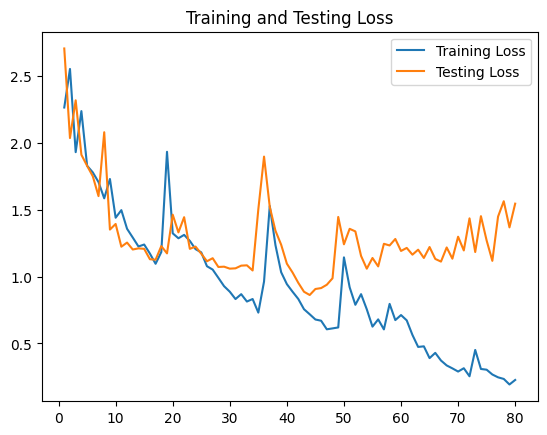

<Figure size 640x480 with 0 Axes>

In [14]:
from matplotlib import pyplot as plt

train_loss = history.history['loss']
eval_loss = history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.plot(epochs,train_loss,label = "Training Loss")
plt.plot(epochs,eval_loss,label = "Testing Loss")

plt.title("Training and Testing Loss")
plt.legend()
plt.figure()
plt.show();

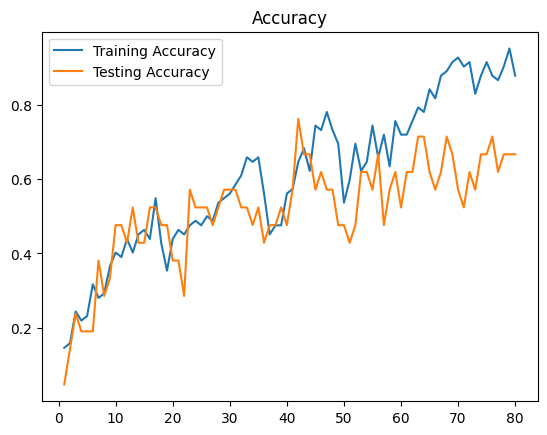

<Figure size 640x480 with 0 Axes>

In [15]:
train_acc = history.history['accuracy']
eval_acc = history.history['val_accuracy']
epochs = range(1, len(train_loss) + 1)
plt.plot(epochs,train_acc,label = "Training Accuracy")
plt.plot(epochs,eval_acc,label = "Testing Accuracy")

plt.title("Accuracy")
plt.legend()
plt.figure()
plt.show();

In [16]:
# Predict probabilities for the test data
probabilities = model.predict(X_val)

# Convert probabilities to class labels
predicted_classes = np.argmax(probabilities, axis=-1)

for i in range(10):
    print(f'Predicted: {label_map[predicted_classes[i]]}, True: {label_map[np.argmax(y_val[i])]}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predicted: quiet, True: quiet
Predicted: sad, True: sad
Predicted: happy, True: happy
Predicted: loud, True: happy
Predicted: happy, True: happy
Predicted: quiet, True: quiet
Predicted: Blind, True: Deaf
Predicted: loud, True: happy
Predicted: loud, True: loud
Predicted: loud, True: loud


In [17]:
# model.save('INCLUDE_8_V1.h5')
try:
    os.mkdir("Model")
except:
    pass

keras.saving.save_model(model, "Model\INCLUDE_8_V3.keras")